# Decision Tree from Scratch — UCI Car Evaluation Dataset

This notebook demonstrates a **DecisionTreeClassifier implemented from scratch using NumPy** on a classic UCI dataset that is especially well-suited for decision trees.

We use the **Car Evaluation dataset**, which is a categorical classification problem involving car acceptability decisions.

Why this dataset is great for decision trees:
- Purely categorical features (ideal for split-based models)
- Nonlinear decision boundaries
- Real-world decision structure (rule-based evaluation)

We will:
- Load dataset from UCI repository
- Encode categorical variables
- Train-test split
- Train decision tree
- Evaluate performance
- Visualize feature usage

---

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from rice_ml import DecisionTreeClassifier
from rice_ml import train_test_split, LabelEncoder, accuracy_score, confusion_matrix

## Load UCI Car Evaluation Dataset

We are predicting the **acceptability of a car**, which is a categorical decision:

- `unacc` → unacceptable
- `acc` → acceptable
- `good` → good
- `vgood` → very good

In other words, the model learns to answer:
> *Given a set of car attributes, how desirable is the car?*

### 🔍 What are we using to predict it?
We use 6 input features that describe the car:

- buying price (vhigh, high, med, low)
- maintenance cost (vhigh, high, med, low)
- number of doors (2, 3, 4, 5more)
- number of persons it can carry (2, 4, more)
- luggage boot size (small, med, big)
- safety rating (low, med, high)

These features are **categorical decision rules**, which makes this dataset especially well-suited for decision trees because splits naturally correspond to human-readable logic.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

cols = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df = pd.read_csv(url, header=None, names=cols)

print(df.head())
print("Dataset shape:", df.shape)

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Dataset shape: (1728, 7)


## Encode Categorical Features

Decision trees in our implementation require numeric thresholds, so we convert categorical variables using label encoding.

In [3]:
encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop("class", axis=1).values
y = df["class"].values

feature_names = cols[:-1]
class_names = encoders["class"].classes_

print("Encoded dataset shape:", X.shape)

Encoded dataset shape: (1728, 6)


## Train-Test Split

We split the dataset into training and testing sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1382, 6)
Test size: (346, 6)


### Train Decision Tree

We train our custom decision tree (max depth = 6).

In [5]:
clf = DecisionTreeClassifier(max_depth=6)
clf.fit(X_train, y_train)

In [6]:
# Predictions
train_preds = clf.predict(X_train)
test_preds = clf.predict(X_test)

### Accuracy Evaluation and Confusion Matrix

Train Accuracy: 0.8929
Test Accuracy:  0.8902


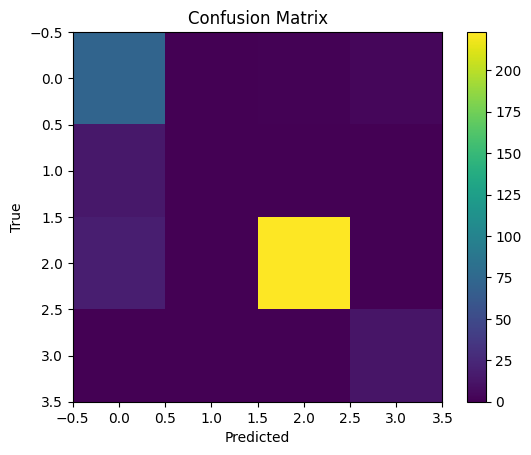

In [8]:
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

cm = confusion_matrix(y_test, test_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


## 🌳 Decision Tree Visualization

We convert the learned tree (stored as nested tuples) into a directed graph and visualize it.

Each internal node shows:
- feature name
- threshold

Each leaf shows the predicted class.

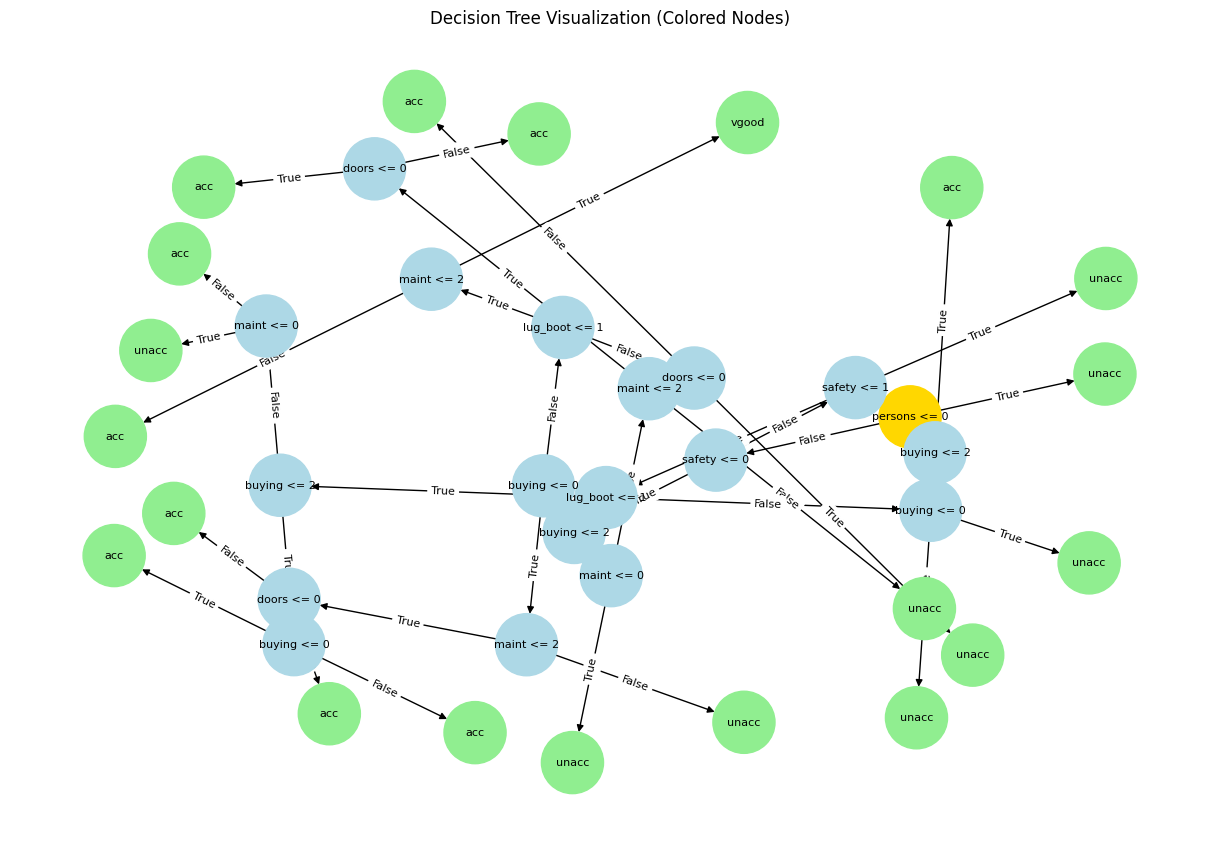

In [15]:
def add_edges(graph, node, parent=None, label="", is_root=False):
    node_id = id(node)

    # LEAF NODE
    if not isinstance(node, tuple):
        graph.add_node(
            node_id,
            label=class_names[node],
            node_type="leaf"
        )
        if parent is not None:
            graph.add_edge(parent, node_id, label=label)
        return node_id

    # DECISION NODE
    feat, thresh, left, right = node

    graph.add_node(
        node_id,
        label=f"{feature_names[feat]} <= {thresh}",
        node_type="root" if is_root else "decision"
    )

    if parent is not None:
        graph.add_edge(parent, node_id, label=label)

    # recurse
    add_edges(graph, left, node_id, "True")
    add_edges(graph, right, node_id, "False")

    return node_id

G = nx.DiGraph()
add_edges(G, clf.root_node, is_root=True)

node_colors = []

for n in G.nodes(data=True):
    node_type = n[1].get("node_type")

    if node_type == "root":
        node_colors.append("gold")
    elif node_type == "decision":
        node_colors.append("lightblue")
    else:  # leaf
        node_colors.append("lightgreen")
        
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

labels = nx.get_node_attributes(G, 'label')
edge_labels = nx.get_edge_attributes(G, 'label')

nx.draw(
    G,
    pos,
    with_labels=True,
    labels=labels,
    node_color=node_colors,
    node_size=2000,
    font_size=8
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Decision Tree Visualization (Colored Nodes)")
plt.show()

## Feature Usage (Split Frequency)
We approximate feature importance by counting how often each feature is used in splits.

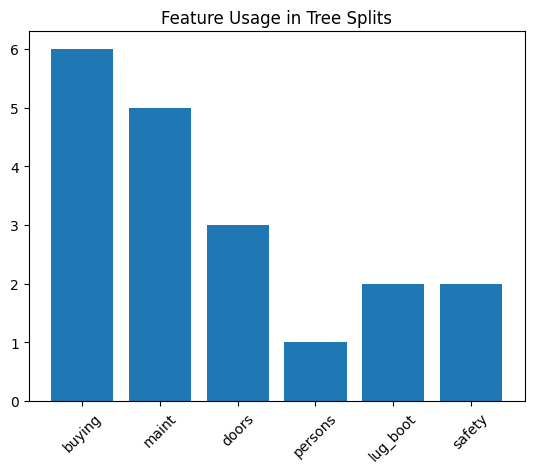

In [9]:
feature_counts = np.zeros(X.shape[1])


def count_splits(node):
    if not isinstance(node, tuple):
        return
    feat, _, left, right = node
    feature_counts[feat] += 1
    count_splits(left)
    count_splits(right)

count_splits(clf.root_node)

plt.figure()
plt.bar(feature_names, feature_counts)
plt.title("Feature Usage in Tree Splits")
plt.xticks(rotation=45)
plt.show()


## Single Prediction Example

In [10]:
sample_idx = 0
sample = X_test[sample_idx]
true_label = y_test[sample_idx]
pred_label = clf.predict(sample.reshape(1, -1))[0]

print("True label:", class_names[true_label])
print("Predicted label:", class_names[pred_label])

True label: acc
Predicted label: acc
